Complete the Statistical Rethinking IRT model for Wines2012 data using PyMC as a practice.

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

In [3]:
df = pd.read_csv("Wines2012.csv")

In [4]:
df.head()

,judge,flight,wine,score,wine.amer,judge.amer
0,Jean-M Cardebat,white,A1,10.0,1,0
1,Jean-M Cardebat,white,B1,13.0,1,0
2,Jean-M Cardebat,white,C1,14.0,0,0
3,Jean-M Cardebat,white,D1,15.0,0,0
4,Jean-M Cardebat,white,E1,8.0,1,0


In [14]:
df["score_std"] = (df.score - df.score.mean()) / df.score.std()
df["judge_ind"] = df.judge.astype("category").cat.codes.values
df["wine_ind"] = df.wine.astype("category").cat.codes.values

In [17]:
n_judges = len(df.judge.unique())
n_wines = len(df.wine.unique())
n_origins = len(df["wine.amer"].unique())

In [19]:
with pm.Model() as model:
    Q = pm.Normal("Q", 0, 1, shape=n_wines)
    O = pm.Normal("O", 0, 1, shape=n_origins)
    H = pm.Normal("H", 0, 1, shape=n_judges)
    D = pm.HalfNormal("D", 1, shape=n_judges)
    sigma = pm.Exponential("sigma", 1)

    mu = (Q[df.wine_ind] + O[df["wine.amer"]] - H[df.judge_ind]) * D[df.judge_ind]

    score = pm.Normal("score", mu=mu, sigma=sigma, observed=df.score_std)

    idata = pm.sample(cores=4, chains=4)

NUTS[nutpie]: [Q, O, H, D, sigma]


Output()

In [20]:
az.summary(idata, kind="diagnostics")

,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Q[0],2029,2522,1.00,0.013,0.0091
Q[1],2570,2792,1.00,0.012,0.0086
Q[2],2763,2809,1.00,0.01,0.0076
Q[3],2620,2478,1.00,0.011,0.0081
Q[4],2984,2869,1.00,0.01,0.008
Q[5],1567,1923,1.00,0.015,0.011
Q[6],2197,2653,1.00,0.013,0.0097
Q[7],2669,2658,1.00,0.011,0.0078
Q[8],2814,2456,1.00,0.011,0.0078
Q[9],2766,2698,1.00,0.01,0.0081


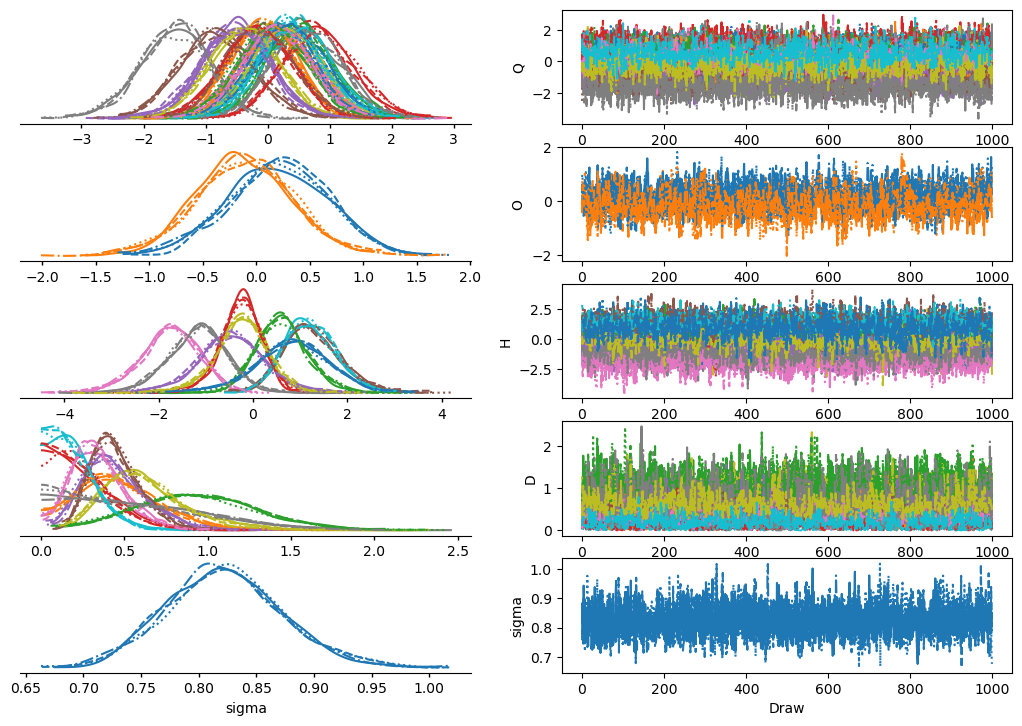

In [21]:
az.plot_trace_dist(idata)

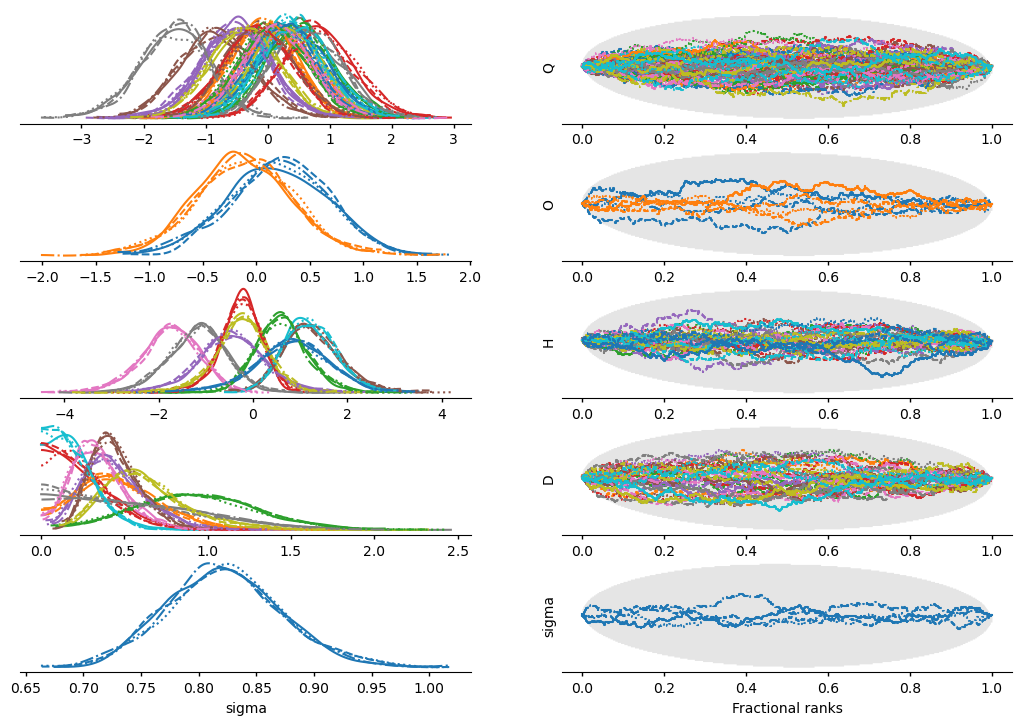

In [22]:
az.plot_rank_dist(idata)

In [23]:
az.summary(idata, kind="stats")

,mean,sd,eti89_lb,eti89_ub
Q[0],0.39,0.57,-0.53,1.3
Q[1],0.17,0.59,-0.73,1.1
Q[2],0.51,0.55,-0.35,1.4
Q[3],0.82,0.58,-0.076,1.8
Q[4],-0.48,0.55,-1.4,0.4
Q[5],-0.82,0.59,-1.8,0.15
Q[6],0.22,0.59,-0.67,1.1
Q[7],0.63,0.56,-0.24,1.5
Q[8],0.28,0.56,-0.61,1.1
Q[9],0.32,0.55,-0.56,1.2
